<a href="https://colab.research.google.com/github/aryac-2006/Machine-Learning-Model/blob/main/Task_27_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.datasets import make_moons

# Generate dataset
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

print(df.head(10))
print("\nShape:", df.shape)

   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959

Shape: (500, 2)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"]).head())

   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


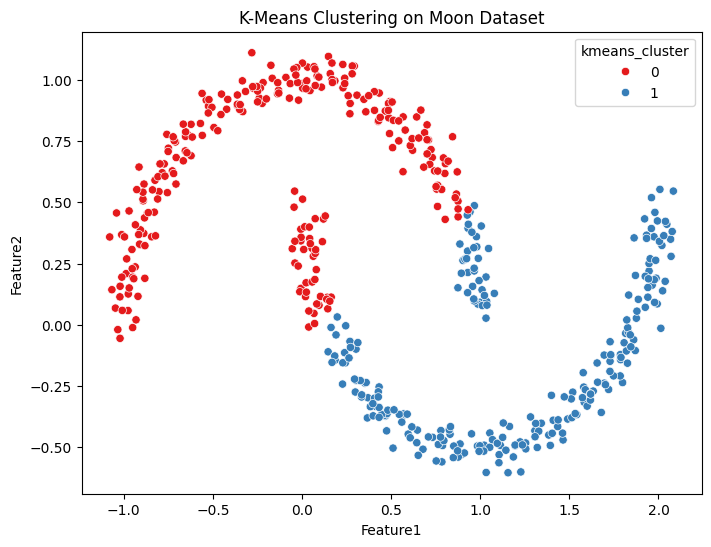

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

kmeans = KMeans(n_clusters=2, random_state=42)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="kmeans_cluster",
    palette="Set1"
)

plt.title("K-Means Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

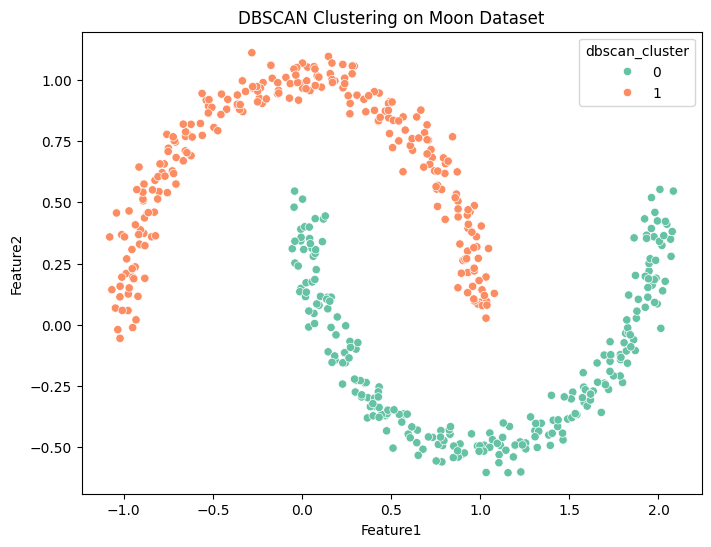

In [5]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="dbscan_cluster",
    palette="Set2"
)

plt.title("DBSCAN Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

In [6]:
print("Observations:")
print("1. KMeans divides the moon-shaped data into two circular clusters.")
print("2. DBSCAN correctly identifies the moon-shaped clusters.")
print("3. DBSCAN can identify noise points.")
print("4. DBSCAN works better for non-linear and irregular-shaped data.")

Observations:
1. KMeans divides the moon-shaped data into two circular clusters.
2. DBSCAN correctly identifies the moon-shaped clusters.
3. DBSCAN can identify noise points.
4. DBSCAN works better for non-linear and irregular-shaped data.


In [7]:
results = []

for eps in [0.2, 0.3, 0.4, 0.5]:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    results.append([eps, clusters, noise])

result_df = pd.DataFrame(
    results,
    columns=["eps", "Clusters", "Noise Points"]
)

print(result_df)

print("\nBest eps value: 0.3")

   eps  Clusters  Noise Points
0  0.2         2             0
1  0.3         2             0
2  0.4         2             0
3  0.5         2             0

Best eps value: 0.3


In [8]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = y

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.64327878 0.21039738]


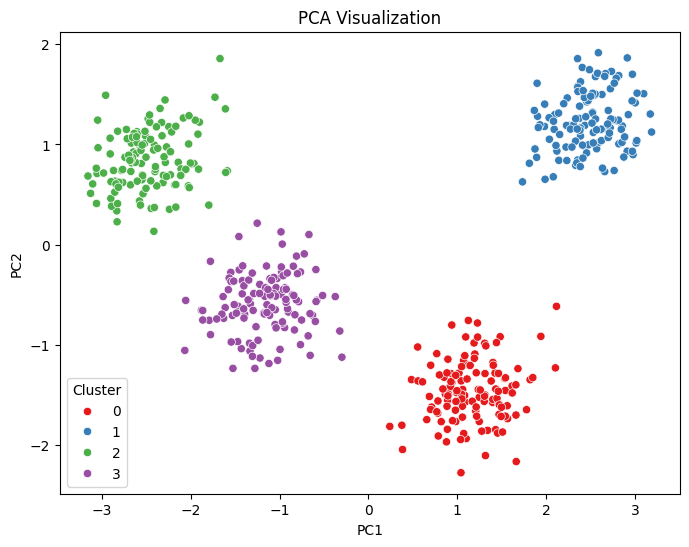

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

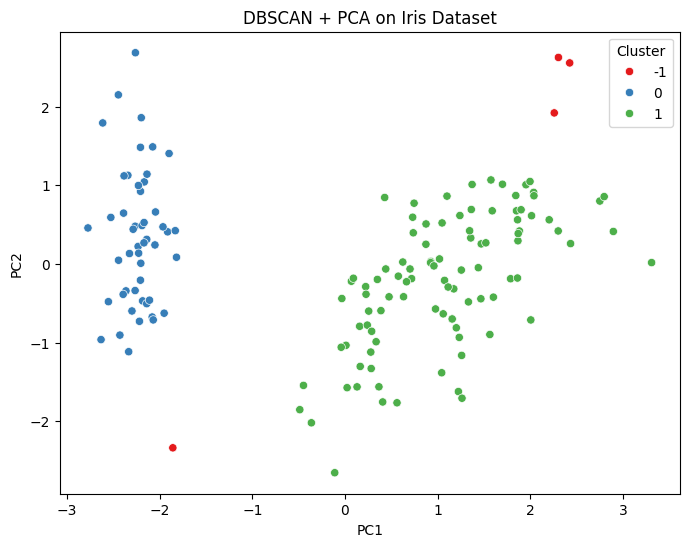

In [12]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Select numerical features
X = df

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# DBSCAN
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

df["Cluster"] = dbscan.fit_predict(X_scaled)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"]

# Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("DBSCAN + PCA on Iris Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()